# Single-image MNIST, knob-free spatial layout (fixed boundary + scale-free repulsion)

Same single-image coupled experiment as `spatial_mnist.ipynb` (784 -> 256 -> 256 -> 10, two-plane
learnable-position spatial regularizer, whole network as one stack of planes) but with the anchor
mechanism **removed** and its job done by two principled changes (`spatial_wrapper_planes_v2.py`,
a subclass -- the original wrapper is untouched):

1. **Fixed boundary planes.** The input plane is pinned to the true 28x28 pixel grid and the 10
   outputs to a fixed circle; neither is trainable. Hidden neurons hang between two fixed, spread
   scaffolds -- wiring attraction toward spread endpoints prevents collapse (the job the anchors
   were doing) and seeds functional geography directly.
2. **Scale-free repulsion.** The hard-shell collision `relu(r-d)^2` (zero beyond r, so no
   long-range spreading; jams once packed) is replaced on the hidden planes by a smooth all-pairs
   Coulomb term `k^2/sqrt(d^2+eps^2)` with `k = sqrt(A*B/n)` -- the natural spacing, computed from
   the plane geometry rather than tuned.

Why the anchor knob existed: the wiring term is pure attraction and the collision term has no
long-range component, so class territories needed an injected spreading force. K ~ 8 worked because
8 diverse+important anchors ~ one pole per class; K = 0 collapses the layout, K = everyone
crystallizes it. Both replacements provide spreading pressure from task-intrinsic quantities, so
there is nothing left to tune.


In [25]:
import copy
import importlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.lines import Line2D
from IPython.display import HTML

import spatial_wrapper_planes_v2 as swp2
swp2 = importlib.reload(swp2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
np.random.seed(0)

A, B, D = 20.0, 20.0, 1.0
GAMMA_SPATIAL = 50.0     # strength of the spatial cost (same as spatial_mnist.ipynb)
EPOCHS  = 20
LR      = 1e-3           # weight learning rate
POS_LR  = 1e-2           # position learning rate
BATCH   = 128
# N_CLASSES is set per-dataset in the data cell below
print(device)

cuda


In [26]:
# ---- dataset toggle: all four are 10-class ----
DATASET = 'CIFAR10'    # 'MNIST' | 'FashionMNIST' | 'KMNIST' | 'CIFAR10' | 'CIFAR100'

# ---- optional frozen ViT feature extractor ----
USE_VIT = False      # if True: embed each image with a frozen pretrained ViT-B/16 (ImageNet)
                     # into 768-d features and train the MLP on those (cf. cifar100_vit_spatial).
                     # ViT features have NO spatial geometry, so the pinned "retina" grid is
                     # arbitrary -- set PIN_INPUTS = False so the input plane self-organizes.

_DATASETS = {   # class, mean, std, (C, H, W), n_classes
    'MNIST':        (torchvision.datasets.MNIST,        (0.1307,), (0.3081,),                 (1, 28, 28),  10),
    'FashionMNIST': (torchvision.datasets.FashionMNIST, (0.2860,), (0.3530,),                 (1, 28, 28),  10),
    'KMNIST':       (torchvision.datasets.KMNIST,       (0.1918,), (0.3483,),                 (1, 28, 28),  10),
    'CIFAR10':      (torchvision.datasets.CIFAR10,
                     (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616),                      (3, 32, 32),  10),
    'CIFAR100':     (torchvision.datasets.CIFAR100,
                     (0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762),                      (3, 32, 32), 100),
}
_ds_cls, _mean, _std, INPUT_SHAPE, N_CLASSES = _DATASETS[DATASET]

if USE_VIT:
    import os
    from torch.utils.data import TensorDataset
    CACHE = f'./data/{DATASET}_vit_feats.pt'
    if os.path.exists(CACHE):
        Xtr, ytr, Xte, yte = torch.load(CACHE)
        print(f"loaded cached ViT features: train {tuple(Xtr.shape)}, test {tuple(Xte.shape)}")
    else:
        weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1
        vit = torchvision.models.vit_b_16(weights=weights).eval().to(device)
        vit.heads = torch.nn.Identity()                       # -> 768-d embedding
        for p in vit.parameters(): p.requires_grad_(False)
        # ViT preprocessing (resize 224 + ImageNet norm) expects 3 channels; upcast grayscale
        _pre = weights.transforms()
        pre = transforms.Compose(([transforms.Grayscale(3)] if INPUT_SHAPE[0] == 1 else []) + [_pre])
        raw_tr = _ds_cls('./data', train=True,  download=True, transform=pre)
        raw_te = _ds_cls('./data', train=False, download=True, transform=pre)
        @torch.no_grad()
        def _embed(ds):
            loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=2)
            feats, labels = [], []
            for xb, yb in loader:
                feats.append(vit(xb.to(device)).cpu()); labels.append(yb)
            return torch.cat(feats), torch.cat(labels)
        print("extracting ViT features (one-time, a few minutes)...", flush=True)
        Xtr, ytr = _embed(raw_tr); Xte, yte = _embed(raw_te)
        os.makedirs(os.path.dirname(CACHE), exist_ok=True)
        torch.save((Xtr, ytr, Xte, yte), CACHE)
        print(f"cached to {CACHE}: train {tuple(Xtr.shape)}, test {tuple(Xte.shape)}")
    mu, sd = Xtr.mean(0, keepdim=True), Xtr.std(0, keepdim=True) + 1e-6   # standardize features
    Xtr, Xte = (Xtr - mu) / sd, (Xte - mu) / sd
    train_ds = TensorDataset(Xtr, ytr); test_ds = TensorDataset(Xte, yte)
    FEAT_DIM = Xtr.shape[1]
else:
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(_mean, _std)])
    train_ds = _ds_cls('./data', train=True,  download=True, transform=transform)
    test_ds  = _ds_cls('./data', train=False, download=True, transform=transform)
    FEAT_DIM = int(np.prod(INPUT_SHAPE))

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=512,   shuffle=False, num_workers=2)
print(f"{DATASET}{' + ViT' if USE_VIT else ''}: FEAT_DIM={FEAT_DIM}, "
      f"train {len(train_ds)}, test {len(test_ds)}")


/opt/miniconda3/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR10: FEAT_DIM=3072, train 50000, test 10000


In [27]:
# ---- optional non-spatial conv front-end (ignored when USE_VIT) ----
USE_CONV      = False   # prepend a single (unspatialized) conv layer before the MLP
CONV_CHANNELS = 16
CONV_KERNEL   = 3
CONV_POOL     = 2       # max-pool factor after the conv (1 = no pool)
if USE_VIT:
    USE_CONV = False    # ViT already replaces the front-end; conv N/A on 768-d features

# geometry the spatialized MLP reads (and that gets pinned as the retina):
if USE_VIT:
    RETINA_SHAPE = (1, 24, 32)             # 768 ViT features on an ARBITRARY 24x32 grid
                                           # (no true geometry -> prefer PIN_INPUTS = False)
elif USE_CONV:
    _C, _H, _W = INPUT_SHAPE
    RETINA_SHAPE = (CONV_CHANNELS, _H // CONV_POOL, _W // CONV_POOL)
else:
    RETINA_SHAPE = INPUT_SHAPE
MLP_FEAT = int(np.prod(RETINA_SHAPE))      # fc1 input size


class MLPs(nn.Module):
    """[optional Conv2d -> ReLU -> MaxPool] -> MLP_FEAT -> 256 -> 256 -> N_CLASSES.
    A conv front-end (if any) is NOT spatialized. With USE_VIT the input is already a
    768-d feature vector, so there is no conv and fc1 reads it directly."""
    def __init__(self, hidden=256):
        super().__init__()
        if USE_CONV:
            self.conv = nn.Conv2d(INPUT_SHAPE[0], CONV_CHANNELS, CONV_KERNEL, padding=CONV_KERNEL // 2)
            self.pool = nn.MaxPool2d(CONV_POOL) if CONV_POOL > 1 else nn.Identity()
        self.fc1 = nn.Linear(MLP_FEAT, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, N_CLASSES)

    def forward(self, x):
        if USE_CONV:
            x = self.pool(F.relu(self.conv(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


@torch.no_grad()
def accuracy_single(model, loader):
    model.eval(); c = t = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        c += (model(x).argmax(1) == y).sum().item(); t += y.numel()
    return 100.0 * c / t

print(f"USE_VIT={USE_VIT} USE_CONV={USE_CONV} -> MLP reads {RETINA_SHAPE} = {MLP_FEAT} features")


USE_VIT=False USE_CONV=False -> MLP reads (3, 32, 32) = 3072 features


## Training

No anchors, no warmup/refresh schedule -- `SpatialNetV2` with its defaults
(`fixed_boundary=True`, `fr_repulsion=True`). Only the hidden planes' positions train;
the optimizer's position group uses `free_position_parameters()` so the pinned
boundary planes are excluded.

In [28]:
# Calibration (20 ep, gamma=50, this exact setup):
#   fixed boundary + FR repulsion : acc 96.5%  LOO centroid in/h1/h2 = 53/42/25%  (null ~7-9%)
#   fixed boundary + collision    : acc 96.7%  LOO 47/27/32%  (hidden planes less separated)
#   free planes    + FR repulsion : acc 93.9%  LOO 50/40/19%
#   old 8-anchor recipe           : acc 94.4%  (naive centroid comparable, needed tuned K/radius/strength)
# --- ablation toggles: which of the two changes is doing the work? ---
PIN_INPUTS   = False    # False: inputs still START at the pixel grid but may move (and get repulsion)
PIN_OUTPUTS  = False    # False: outputs start on the circle but may move
REPULSION = 'exp'       # repulsion on free planes:
                       #   'fr'        k^2/sqrt(d^2+eps^2) -- scale-free, long-range, UNBOUNDED
                       #               (inflates free planes; small planes worst -- see the outputs)
                       #   'exp'       exp(-d)             -- Wolczyk et al. 2019 term; short-range,
                       #               self-limiting -> keeps a freed output plane bounded
                       #   'collision' relu(r-d)^2         -- original hard-shell collision

def train_single_coupled(epochs=EPOCHS):
    torch.manual_seed(0)
    net = swp2.SpatialNetV2(MLPs().to(device), A, B, D, device=device,
                            input_shape=RETINA_SHAPE,  # retina = raw pixels, or conv feature map if USE_CONV
                            fixed_boundary=True,
                            pin_inputs=PIN_INPUTS, pin_outputs=PIN_OUTPUTS,
                            repulsion=REPULSION).to(device)
    optimizer = Adam([
        {'params': net.model.parameters(), 'lr': LR},
        {'params': net.free_position_parameters(), 'lr': POS_LR},
    ])
    hist = {'test_acc': [], 'sparsity': [], 'planes': [], 'weights': []}

    def snap():
        hist['planes'].append([[c.detach().cpu().clone() for c in pr] for pr in net.coupled_planes()])
        hist['weights'].append([l.weight.detach().abs().cpu().clone() for l in net.linear_layers])

    snap()
    for epoch in range(1, epochs + 1):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = F.cross_entropy(net(x), y) + GAMMA_SPATIAL * net.get_cost()
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        snap()
        acc = accuracy_single(net, test_loader); hist['test_acc'].append(acc)
        w = torch.cat([l.weight.detach().abs().flatten() for l in net.linear_layers])
        sp = 100.0 * (w < 1e-3).float().mean().item(); hist['sparsity'].append(sp)
        print(f"[single] epoch {epoch}/{epochs}  test acc {acc:.2f}%  sparsity(<1e-3) {sp:.1f}%", flush=True)
    return net, hist

single_model, histS = train_single_coupled()

[single] epoch 1/20  test acc 41.91%  sparsity(<1e-3) 84.5%
[single] epoch 2/20  test acc 44.88%  sparsity(<1e-3) 88.0%
[single] epoch 3/20  test acc 46.66%  sparsity(<1e-3) 89.2%
[single] epoch 4/20  test acc 46.58%  sparsity(<1e-3) 89.4%
[single] epoch 5/20  test acc 47.33%  sparsity(<1e-3) 89.6%
[single] epoch 6/20  test acc 48.38%  sparsity(<1e-3) 89.6%
[single] epoch 7/20  test acc 48.53%  sparsity(<1e-3) 89.8%
[single] epoch 8/20  test acc 48.82%  sparsity(<1e-3) 89.3%
[single] epoch 9/20  test acc 49.60%  sparsity(<1e-3) 89.3%
[single] epoch 10/20  test acc 49.58%  sparsity(<1e-3) 89.6%
[single] epoch 11/20  test acc 49.66%  sparsity(<1e-3) 89.3%
[single] epoch 12/20  test acc 49.57%  sparsity(<1e-3) 89.2%
[single] epoch 13/20  test acc 49.26%  sparsity(<1e-3) 89.5%
[single] epoch 14/20  test acc 49.81%  sparsity(<1e-3) 89.4%
[single] epoch 15/20  test acc 50.06%  sparsity(<1e-3) 89.6%
[single] epoch 16/20  test acc 50.65%  sparsity(<1e-3) 89.5%
[single] epoch 17/20  test acc 50

## Visualization: class colouring, live masks, whole-network 3D plot

Preferred class per neuron via backward products of |W|, **row-normalized** per class before the
argmax so a couple of high-weight-mass classes cannot claim every neuron.

In [29]:
DEAD_THRESH = 1e-2   # a neuron with ALL incoming OR ALL outgoing |W| below this is "dead" -> not drawn

def live_masks(weights, n_planes, thr=DEAD_THRESH):
    """Boolean live-mask per plane, with PROPAGATING death (see spatial_mnist.ipynb)."""
    n_layers = len(weights)
    sizes = [weights[p].shape[1] if p < n_layers else weights[p - 1].shape[0] for p in range(n_planes)]
    present = [w >= thr for w in weights]
    alive = [torch.ones(s, dtype=torch.bool) for s in sizes]
    changed = True
    while changed:
        changed = False
        for p in range(n_planes):
            new = torch.ones(sizes[p], dtype=torch.bool)
            if p > 0:
                new &= (present[p - 1] & alive[p - 1].unsqueeze(0)).any(dim=1)
            if p < n_layers:
                new &= (present[p] & alive[p + 1].unsqueeze(1)).any(dim=0)
            new &= alive[p]
            if (new != alive[p]).any():
                alive[p] = new; changed = True
    return alive


def preferred_class_single(model):
    """Per-plane preferred output class via row-normalized backward products of |W|."""
    W1 = model.fc1.weight.detach().abs().cpu()
    W2 = model.fc2.weight.detach().abs().cpu()
    W3 = model.fc3.weight.detach().abs().cpu()
    def norm_argmax(M):
        return (M / (M.sum(1, keepdim=True) + 1e-9)).argmax(0)
    return [norm_argmax(W3 @ W2 @ W1), norm_argmax(W3 @ W2), norm_argmax(W3),
            torch.arange(N_CLASSES)]

plane_clsS    = preferred_class_single(single_model.model)
plane_labelsS = [f'input ({MLP_FEAT})', 'hidden-1 (256)', 'hidden-2 (256)', f'output ({N_CLASSES})']
snapsS = histS['planes']; wsnapsS = histS['weights']; n_epS = len(snapsS)
# colormap that scales with class count; a legend only stays readable when small
if N_CLASSES <= 10:
    cmapN = plt.get_cmap('tab10', N_CLASSES)
elif N_CLASSES <= 20:
    cmapN = plt.get_cmap('tab20', N_CLASSES)
else:
    cmapN = plt.get_cmap('gist_ncar', N_CLASSES)   # 100 classes: dense but distinct-ish
USE_LEGEND = N_CLASSES <= 20

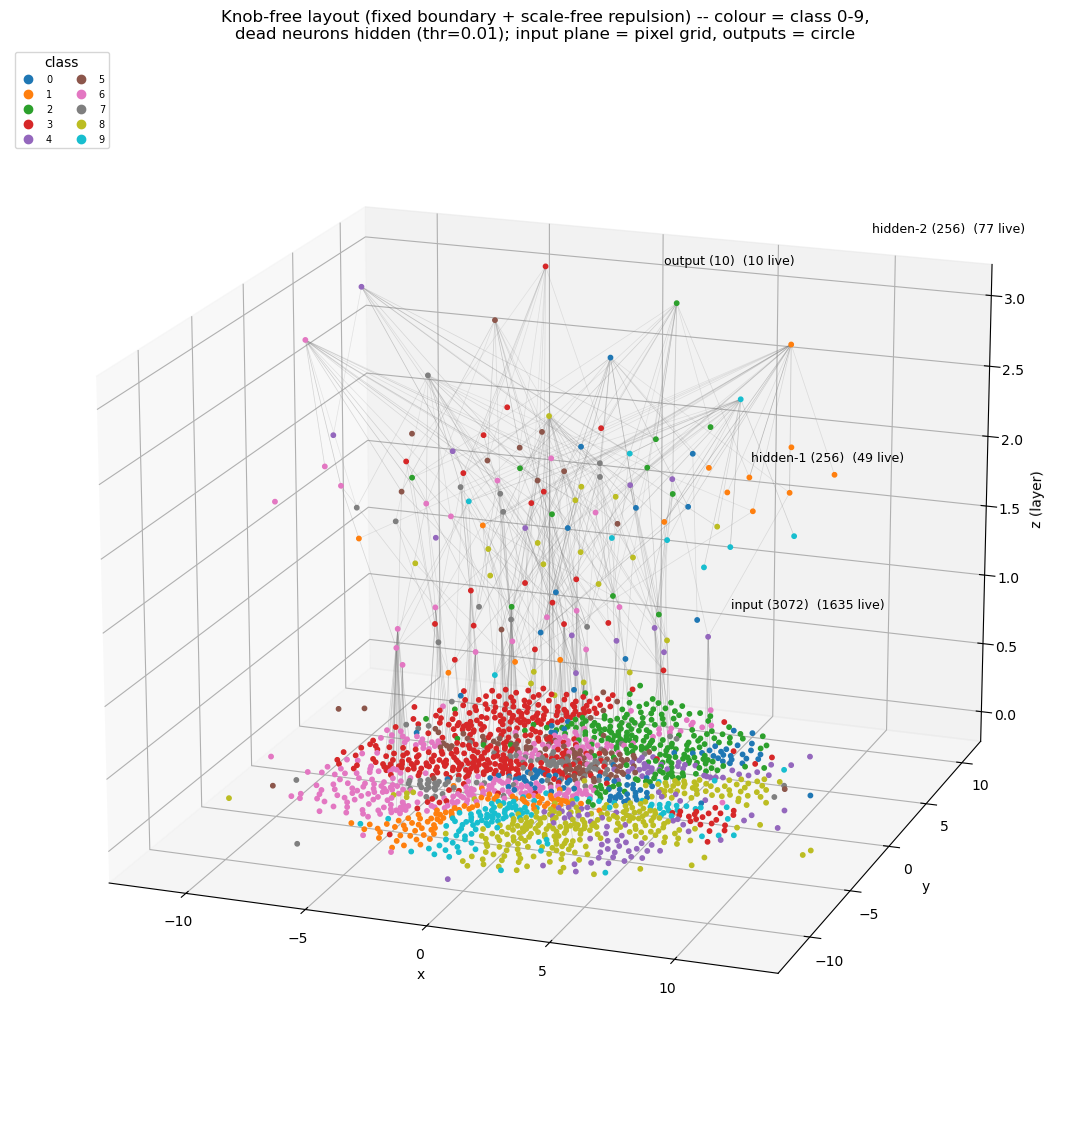

In [30]:
def plot_net_classes(planes, weights, cls, k_lines=150, elev=18, azim=-70):
    live = live_masks(weights, len(planes))
    fig = plt.figure(figsize=(11, 13)); ax = fig.add_subplot(111, projection='3d')
    for i, (xy, c) in enumerate(zip(planes, cls)):
        m = live[i].numpy()
        x, y = xy[0].numpy()[m], xy[1].numpy()[m]
        ax.scatter(x, y, np.full(int(m.sum()), i * D),
                   c=[cmapN(int(k) % N_CLASSES) for k in c.numpy()[m]], s=10, depthshade=False)
        ax.text(0, xy[1].numpy().max() + 2, i * D, f'{plane_labelsS[i]}  ({int(m.sum())} live)', fontsize=9)
    for i in range(len(planes) - 1):
        li, lo = live[i], live[i + 1]
        xin, yin = planes[i][0].numpy(), planes[i][1].numpy()
        xo, yo = planes[i + 1][0].numpy(), planes[i + 1][1].numpy()
        W = weights[i].clone(); W[~lo, :] = 0; W[:, ~li] = 0
        wmax = weights[i].max()
        idx = torch.topk(W.flatten(), min(k_lines, W.numel())).indices
        rows, cols = idx // W.shape[1], idx % W.shape[1]
        for r, cc in zip(rows.tolist(), cols.tolist()):
            if W[r, cc] == 0:
                continue
            ax.plot([xin[cc], xo[r]], [yin[cc], yo[r]], [i * D, (i + 1) * D],
                    c='gray', alpha=min(1.0, 0.05 + 0.5 * (W[r, cc] / wmax).item()), lw=0.5)
    if USE_LEGEND:
        handles = [Line2D([0], [0], marker='o', ls='', color=cmapN(k), label=str(k)) for k in range(N_CLASSES)]
        ax.legend(handles=handles, title='class', loc='upper left', fontsize=7,
                  ncol=2 if N_CLASSES <= 10 else 4)
    else:
        import matplotlib as mpl
        sm = mpl.cm.ScalarMappable(cmap=cmapN, norm=mpl.colors.Normalize(vmin=0, vmax=N_CLASSES - 1))
        fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.1, label='class')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z (layer)')
    ax.set_title(f'Knob-free layout (fixed boundary + scale-free repulsion) -- colour = class 0-{N_CLASSES-1},\n'
                 f'dead neurons hidden (thr={DEAD_THRESH:g}); input plane = pixel grid, outputs = circle')
    plt.tight_layout(); plt.show()

plot_net_classes(snapsS[-1], wsnapsS[-1], plane_clsS)

In [31]:
# Per-class neuron counts: for each class, how many LIVE neurons on each plane were
# assigned it (assignment = row-normalized backward-|W| argmax, from preferred_class_single).
# Counts are a WINNER-TAKE-ALL vote over near-flat scores, so read them as a rough capacity
# proxy, not exact allocation -- a class can still classify well with ~0 assigned hidden
# neurons (its computation lives in neurons labelled for other classes).
@torch.no_grad()
def per_class_accuracy(model, loader, n_classes):
    model.eval()
    correct = torch.zeros(n_classes); total = torch.zeros(n_classes)
    for x, y in loader:
        pred = model(x.to(device)).argmax(1).cpu()
        for c in range(n_classes):
            mask = (y == c)
            correct[c] += (pred[mask] == c).sum(); total[c] += mask.sum()
    return (correct / total.clamp(min=1)).numpy()

class_acc = per_class_accuracy(single_model, test_loader, N_CLASSES)
live      = live_masks(wsnapsS[-1], len(snapsS[-1]))
n_planes  = len(snapsS[-1])

rows = []
for c in range(N_CLASSES):
    per_plane = [int(((plane_clsS[p].numpy() == c) & live[p].numpy()).sum()) for p in range(n_planes)]
    rows.append((c, per_plane, sum(per_plane)))

hdr = "  ".join(f"{plane_labelsS[p].split()[0]:>8}" for p in range(n_planes))
print(f"{'cls':>4} {'acc%':>6} {'total':>6}  {hdr}")
print("-" * (24 + 10 * n_planes))
for c, per_plane, tot in sorted(rows, key=lambda r: -r[2]):
    print(f"{c:>4} {100*class_acc[c]:>6.1f} {tot:>6}  " + "  ".join(f"{n:>8}" for n in per_plane))

totals = np.array([r[2] for r in sorted(rows, key=lambda r: r[0])], dtype=float)
print(f"\ncorr(neurons per class, accuracy) = {np.corrcoef(totals, class_acc)[0, 1]:.3f}")
print("sum of per-class totals:", int(totals.sum()),
      " | total live neurons:", sum(int(l.sum()) for l in live), " (should match)")


 cls   acc%  total     input  hidden-1  hidden-2    output
----------------------------------------------------------------
   3   34.2    386       367        11         7         1
   8   58.9    276       257         6        12         1
   6   62.9    267       248        10         8         1
   2   37.6    216       205         3         7         1
   9   58.4    117       108         1         7         1
   4   33.1    111        98         6         6         1
   5   42.4    104        94         1         8         1
   0   65.3    100        90         4         5         1
   7   53.9     99        87         4         7         1
   1   59.8     95        81         3        10         1

corr(neurons per class, accuracy) = -0.248
sum of per-class totals: 1771  | total live neurons: 1771  (should match)


class 0 test acc: 65.3%


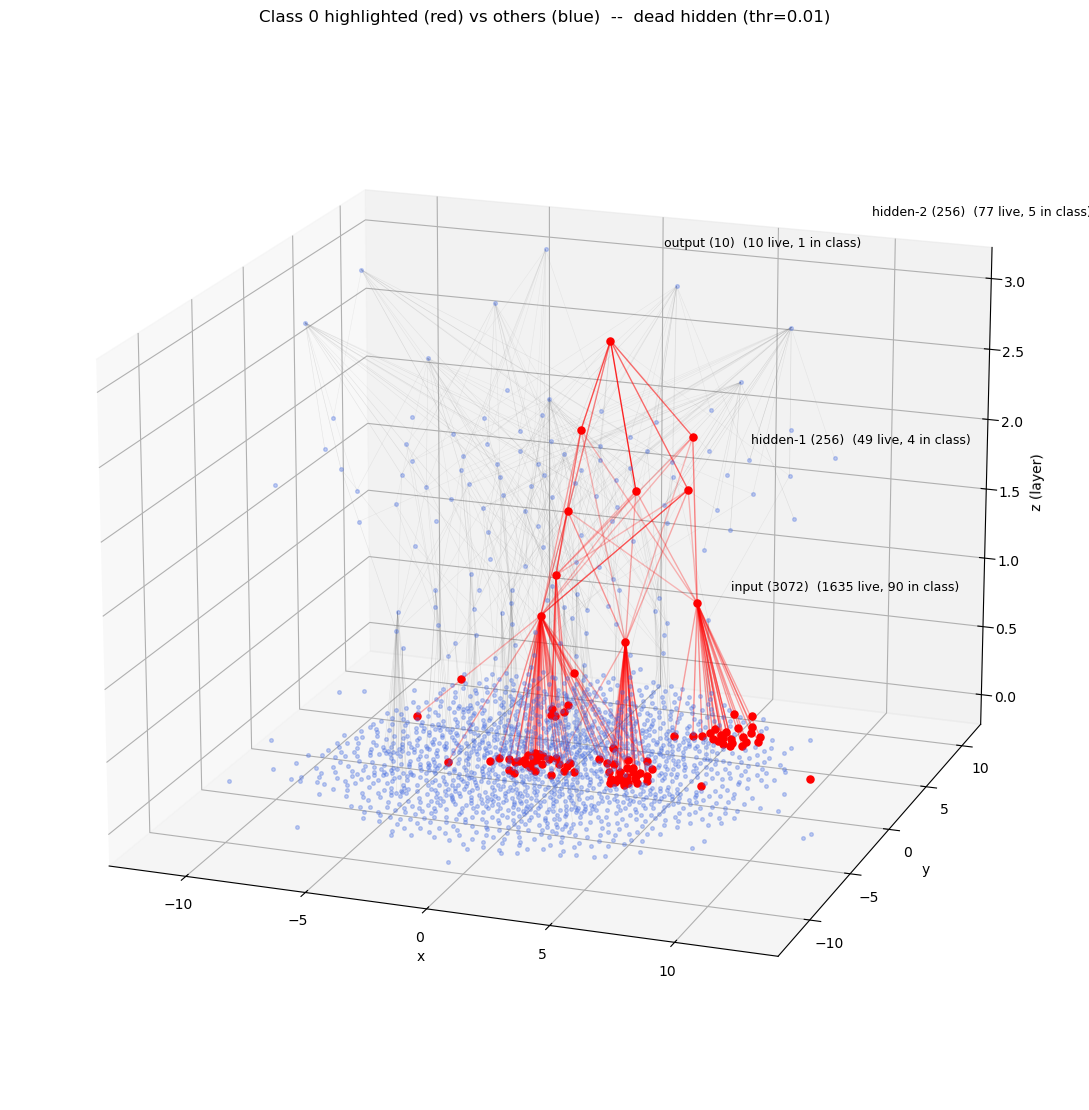

In [32]:
# Single-class highlight (2 colours): neurons whose preferred class == HIGHLIGHT_CLASS are
# red, everything else blue; edges with BOTH endpoints in the class are red too. Same
# assignment scheme (row-normalized backward-|W| argmax) as the full colour plot -- useful
# for CIFAR-100 where 100 colours in one plot are unreadable. Edit HIGHLIGHT_CLASS and re-run.
HIGHLIGHT = 'red'; OTHER = 'royalblue'

def plot_net_one_class(planes, weights, cls, target, k_lines=150, edge_topk_hi=80, elev=18, azim=-70):
    live = live_masks(weights, len(planes))
    fig = plt.figure(figsize=(11, 13)); ax = fig.add_subplot(111, projection='3d')
    # ---- nodes ----
    for i, (xy, c) in enumerate(zip(planes, cls)):
        m = live[i].numpy()
        x, y = xy[0].numpy()[m], xy[1].numpy()[m]
        z = np.full(int(m.sum()), i * D)
        is_hi = (c.numpy()[m] == target)
        if (~is_hi).any():
            ax.scatter(x[~is_hi], y[~is_hi], z[~is_hi], c=OTHER, s=7, depthshade=False, alpha=0.30)
        if is_hi.any():
            ax.scatter(x[is_hi], y[is_hi], z[is_hi], c=HIGHLIGHT, s=26, depthshade=False)
        ax.text(0, xy[1].numpy().max() + 2, i * D,
                f'{plane_labelsS[i]}  ({int(m.sum())} live, {int(is_hi.sum())} in class)', fontsize=9)
    # ---- edges ----
    for i in range(len(planes) - 1):
        li, lo = live[i], live[i + 1]
        xin, yin = planes[i][0].numpy(), planes[i][1].numpy()
        xo, yo = planes[i + 1][0].numpy(), planes[i + 1][1].numpy()
        W = weights[i].clone(); W[~lo, :] = 0; W[:, ~li] = 0
        wmax = weights[i].max()
        hi_out = (cls[i + 1].numpy() == target)   # rows  = plane i+1 neurons
        hi_in  = (cls[i].numpy()     == target)   # cols  = plane i   neurons
        both = torch.from_numpy(hi_out[:, None] & hi_in[None, :])
        idx = torch.topk(W.flatten(), min(k_lines, W.numel())).indices     # background (gray)
        for r, cc in zip((idx // W.shape[1]).tolist(), (idx % W.shape[1]).tolist()):
            if W[r, cc] == 0 or bool(both[r, cc]):
                continue
            ax.plot([xin[cc], xo[r]], [yin[cc], yo[r]], [i * D, (i + 1) * D],
                    c='gray', alpha=min(0.4, 0.03 + 0.3 * (W[r, cc] / wmax).item()), lw=0.4)
        Whi = W.clone(); Whi[~both] = 0                                    # in-class edges (red)
        if Whi.max() > 0:
            hidx = torch.topk(Whi.flatten(), min(edge_topk_hi, Whi.numel())).indices
            for r, cc in zip((hidx // Whi.shape[1]).tolist(), (hidx % Whi.shape[1]).tolist()):
                if Whi[r, cc] == 0:
                    continue
                ax.plot([xin[cc], xo[r]], [yin[cc], yo[r]], [i * D, (i + 1) * D],
                        c=HIGHLIGHT, alpha=min(1.0, 0.25 + 0.6 * (Whi[r, cc] / wmax).item()), lw=1.0)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z (layer)')
    ax.set_title(f'Class {target} highlighted (red) vs others (blue)  --  dead hidden (thr={DEAD_THRESH:g})')
    plt.tight_layout(); plt.show()

# ---- pick the class to highlight (0-indexed) ----
HIGHLIGHT_CLASS = 0
if 'class_acc' in globals():
    print(f'class {HIGHLIGHT_CLASS} test acc: {100*class_acc[HIGHLIGHT_CLASS]:.1f}%')
plot_net_one_class(snapsS[-1], wsnapsS[-1], plane_clsS, target=HIGHLIGHT_CLASS)


## Whole network forming over training (dead neurons hidden per frame)

The boundary planes stay put; only the hidden planes move.

In [33]:
# One FIXED live set (from the final weights) for every frame. Recomputing the mask
# per frame makes border pixels vanish as training sparsifies, so the pinned input
# grid appears to "contract into a circle" (the central ink region) even though no
# position moves. With a fixed mask, pinned planes render rock-static.
liveF = live_masks(wsnapsS[-1], len(snapsS[-1]))

# Axis limits from LIVE neurons only: dead neurons feel only repulsion (no wiring
# attraction), drift far out over training, and would zoom the camera way out.
allcS = np.concatenate([np.concatenate([snapsS[t][i][j].numpy()[liveF[i].numpy()]
                        for i in range(len(snapsS[t])) for j in (0, 1)]) for t in range(n_epS)])
limS = (allcS.min() - 1, allcS.max() + 1)
fig = plt.figure(figsize=(9, 11)); ax = fig.add_subplot(111, projection='3d')

def draw_single(t):
    ax.cla()
    planes = snapsS[t]; weights = wsnapsS[t]
    live = liveF
    for i, (xy, c) in enumerate(zip(planes, plane_clsS)):
        m = live[i].numpy()
        x, y = xy[0].numpy()[m], xy[1].numpy()[m]
        ax.scatter(x, y, np.full(int(m.sum()), i * D),
                   c=[cmapN(int(k) % N_CLASSES) for k in c.numpy()[m]], s=8, depthshade=False)
        ax.text(limS[0], limS[1], i * D, plane_labelsS[i], fontsize=8)
    for i in range(len(planes) - 1):
        li, lo = live[i], live[i + 1]
        xin, yin = planes[i][0].numpy(), planes[i][1].numpy()
        xo, yo = planes[i + 1][0].numpy(), planes[i + 1][1].numpy()
        W = weights[i].clone(); W[~lo, :] = 0; W[:, ~li] = 0
        wmax = weights[i].max()
        idx = torch.topk(W.flatten(), min(150, W.numel())).indices
        rows, cols = idx // W.shape[1], idx % W.shape[1]
        for r, cc in zip(rows.tolist(), cols.tolist()):
            if W[r, cc] == 0:
                continue
            ax.plot([xin[cc], xo[r]], [yin[cc], yo[r]], [i * D, (i + 1) * D],
                    c='gray', alpha=min(1.0, 0.05 + 0.5 * (W[r, cc] / wmax).item()), lw=0.4)
    ax.set_xlim(limS); ax.set_ylim(limS); ax.set_zlim(0, (len(planes) - 1) * D); ax.view_init(18, -70)
    ax.set_title(f'knob-free whole network - epoch {t}/{n_epS - 1}')

anim_single = animation.FuncAnimation(fig, draw_single, frames=n_epS, interval=700)
plt.close(fig)
HTML(anim_single.to_jshtml())

## Class separability: naive + leave-one-out centroid, with permutation null

LOO excludes each neuron from its own class centroid (singleton classes count as wrong), so
tiny classes cannot inflate the score; the null is 200 label shuffles.

In [34]:
from scipy.spatial.distance import cdist

def loo_centroid_acc(P, lab, rng=None):
    if rng is not None:
        lab = rng.permutation(lab)
    classes, correct = np.unique(lab), 0
    sums = {c: P[lab == c].sum(0) for c in classes}
    cnts = {c: (lab == c).sum() for c in classes}
    for i in range(len(P)):
        cents, names = [], []
        for c in classes:
            n = cnts[c] - (lab[i] == c)
            if n == 0: continue
            s = sums[c] - (P[i] if lab[i] == c else 0)
            cents.append(s / n); names.append(c)
        pred = names[int(cdist(P[i:i+1], np.stack(cents)).argmin())]
        correct += (pred == lab[i])
    return 100 * correct / len(P)

rng = np.random.default_rng(0)
live = live_masks(wsnapsS[-1], len(snapsS[-1]))
print(f"{'plane':18s} {'live':>5} {'naive%':>7} {'LOO%':>6} {'null mean':>10} {'null 95th':>10}")
for i, (xy, c) in enumerate(zip(snapsS[-1], plane_clsS)):
    if i == len(snapsS[-1]) - 1:
        continue
    m = live[i].numpy()
    P = np.stack([xy[0].numpy()[m], xy[1].numpy()[m]], 1)
    lab = c.numpy()[m]
    if len(np.unique(lab)) < 2 or m.sum() < 3:
        print(f"{plane_labelsS[i]:18s} {int(m.sum()):>5}  too few live neurons"); continue
    cents = np.stack([P[lab == cc].mean(0) for cc in np.unique(lab)])
    naive = 100 * (np.unique(lab)[cdist(P, cents).argmin(1)] == lab).mean()
    real = loo_centroid_acc(P, lab)
    null = np.array([loo_centroid_acc(P, lab, rng) for _ in range(200)])
    print(f"{plane_labelsS[i]:18s} {int(m.sum()):>5} {naive:>6.1f}% {real:>5.1f}% "
          f"{null.mean():>9.1f}% {np.percentile(null, 95):>9.1f}%")

plane               live  naive%   LOO%  null mean  null 95th


input (3072)        1635   35.7%  35.4%       7.8%      11.6%
hidden-1 (256)        49   34.7%  22.4%       8.9%      18.4%
hidden-2 (256)        77   41.6%  36.4%      10.0%      16.9%


## Circuits vs. geometry: Louvain communities (label-free)

Detect circuits from **connectivity alone** -- Louvain on the whole-network |W| graph, no class
labels -- then test whether those communities are spatially compact. This asks whether the
network's *own* modular decomposition aligns with location, a stronger and label-free version of
the class-coloring test (no argmax degeneracy, no assumption that circuit = class). Reports graph
modularity Q, the communities' spatial silhouette vs a label-shuffle null, and NMI(community, class)
-- how much the connectivity circuits coincide with the class labels (1 = identical, 0 = unrelated).


In [35]:
# Method 3: graph communities (Louvain) vs geometry. Circuits are defined by CONNECTIVITY,
# not by class labels -- one graph over all live neurons across the coupled stack, edges = |W|
# between adjacent planes. Communities are then tested for spatial compactness.
try:
    import igraph as ig
except ImportError:
    ig = None; print("pip install python-igraph to run this cell")
from collections import Counter
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

def whole_network_communities(planes, weights, live, thr=DEAD_THRESH):
    """One undirected graph over all LIVE neurons in the coupled stack; edges = |W| >= thr
    between adjacent planes. Returns per-node plane index, 3D positions (x, y, z=layer),
    Louvain community labels, and the graph modularity Q."""
    gid = {}; pos = []; node_plane = []; n = 0
    for p, xy in enumerate(planes):
        m = live[p].numpy(); x = xy[0].numpy(); y = xy[1].numpy()
        for loc in np.where(m)[0]:
            gid[(p, loc)] = n; pos.append((x[loc], y[loc], p * D)); node_plane.append(p); n += 1
    edges = []; ew = []
    for i, W in enumerate(weights):
        Wn = W.numpy(); li = live[i].numpy(); lo = live[i + 1].numpy()
        rr, cc = np.where((Wn >= thr) & lo[:, None] & li[None, :])
        for r, c in zip(rr.tolist(), cc.tolist()):
            edges.append((gid[(i, c)], gid[(i + 1, r)])); ew.append(float(Wn[r, c]))
    g = ig.Graph(n=n, edges=edges, directed=False); g.es['weight'] = ew
    comm = g.community_multilevel(weights='weight')
    return np.array(node_plane), np.array(pos), np.array(comm.membership), g.modularity(comm, weights='weight')

if ig is not None:
    live = live_masks(wsnapsS[-1], len(snapsS[-1]))
    node_plane, pos3d, comm_lab, Q = whole_network_communities(snapsS[-1], wsnapsS[-1], live)
    print(f"Louvain on |W| graph: {len(comm_lab)} live neurons, {len(set(comm_lab))} communities, "
          f"modularity Q = {Q:.3f}")

    # spatial compactness of communities (3D positions), vs a label-shuffle null.
    # keep communities with >= 3 members so silhouette is meaningful.
    keep = np.array([Counter(comm_lab)[c] >= 3 for c in comm_lab])
    P, L = pos3d[keep], comm_lab[keep]
    rng = np.random.default_rng(0)
    def sil(P, L, shuffle=False):
        if shuffle: L = rng.permutation(L)
        return silhouette_score(P, L) if len(np.unique(L)) > 1 else np.nan
    s = sil(P, L); null = np.array([sil(P, L, True) for _ in range(200)])
    print(f"community spatial silhouette (3D) = {s:.3f}   "
          f"(null {null.mean():.3f}, 95th {np.percentile(null, 95):.3f})")
    print(f"  -> {'above' if s > np.percentile(null, 95) else 'NOT above'} the 95th-percentile null "
          f"=> circuits {'are' if s > np.percentile(null, 95) else 'are not'} spatially clustered")

    # how much do the connectivity circuits coincide with the class labels?
    cls_all = np.concatenate([plane_clsS[p].numpy()[live[p].numpy()] for p in range(len(live))])
    nmi = normalized_mutual_info_score(comm_lab, cls_all)
    print(f"NMI(community, preferred-class) = {nmi:.3f}   (1 = circuits ARE classes, 0 = unrelated)")

    # per-community: size and which planes it spans (a full-depth 'column' spans all planes)
    print(f"\n{'comm':>5} {'size':>5}   planes spanned")
    for c in sorted(set(comm_lab), key=lambda c: -Counter(comm_lab)[c]):
        m = comm_lab == c
        print(f"{c:>5} {int(m.sum()):>5}   {sorted(set(node_plane[m].tolist()))}")


Louvain on |W| graph: 1771 live neurons, 9 communities, modularity Q = 0.548
community spatial silhouette (3D) = 0.203   (null -0.051, 95th -0.036)
  -> above the 95th-percentile null => circuits are spatially clustered
NMI(community, preferred-class) = 0.333   (1 = circuits ARE classes, 0 = unrelated)

 comm  size   planes spanned
    6   295   [0, 1, 2]
    0   268   [0, 1, 2]
    3   238   [0, 1, 2]
    2   235   [0, 1, 2]
    4   213   [0, 1, 2]
    1   206   [0, 1, 2]
    7   147   [0, 1, 2]
    5   103   [0, 1]
    8    66   [2, 3]


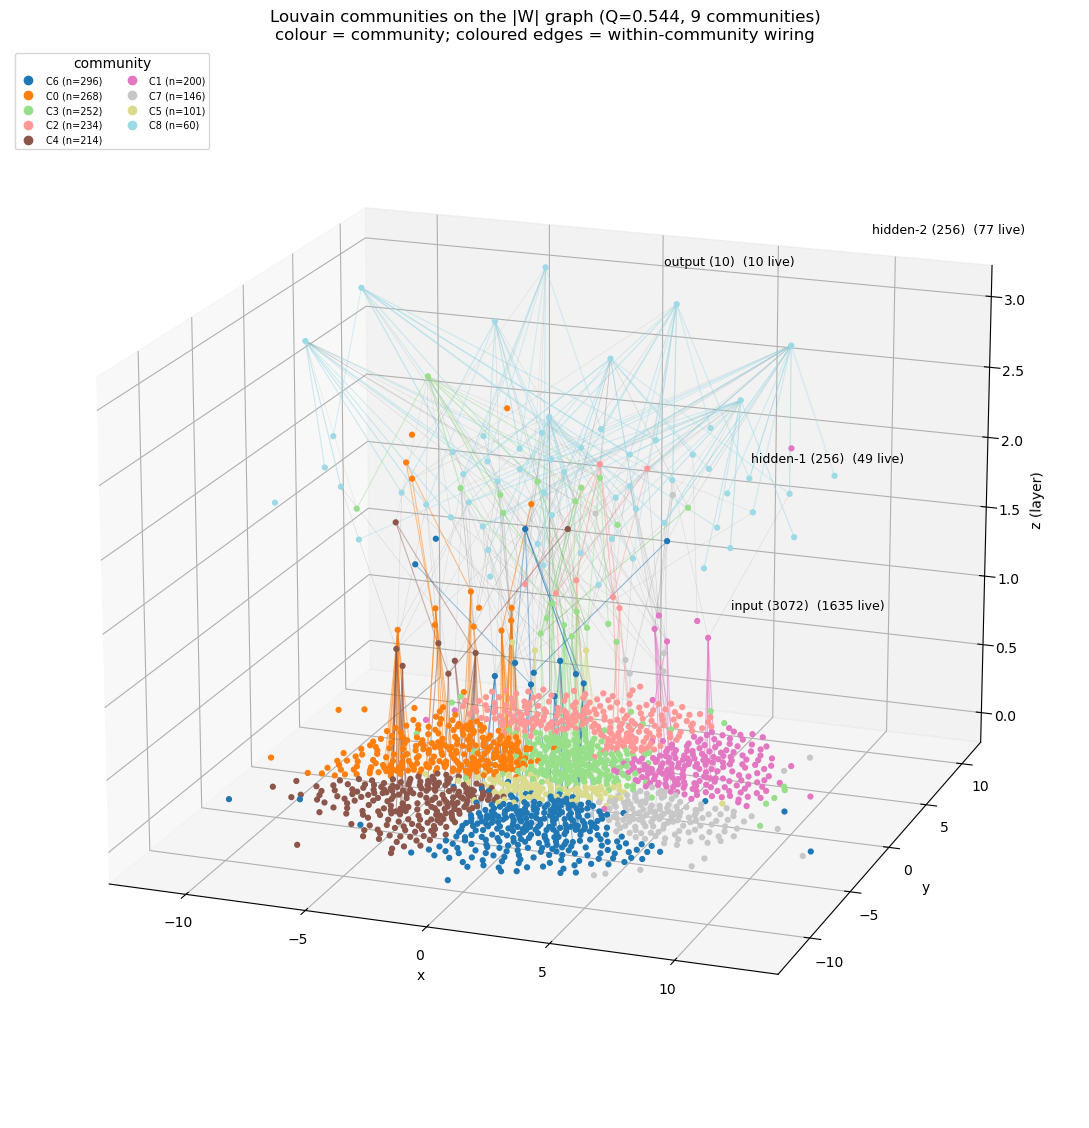

In [36]:
# Colour + plot the Louvain communities in 3D (run the 'Circuits vs. geometry' cell first).
# Nodes coloured by community; within-community wires are coloured, cross-community wires gray.
import matplotlib as mpl
from matplotlib.lines import Line2D
from collections import Counter

live = live_masks(wsnapsS[-1], len(snapsS[-1]))
node_plane, pos3d, comm_lab, Q = whole_network_communities(snapsS[-1], wsnapsS[-1], live)

# map flat community labels back to a per-plane array (dead neurons -> -1)
comm_per_plane = [np.full(live[p].numel(), -1) for p in range(len(live))]
gi = 0
for p in range(len(live)):
    for loc in np.where(live[p].numpy())[0]:
        comm_per_plane[p][loc] = comm_lab[gi]; gi += 1

n_comm = int(comm_lab.max()) + 1
order = [c for c, _ in Counter(comm_lab).most_common()]          # big circuits first
palette = plt.get_cmap('tab20', max(n_comm, 1))
col_of = {c: palette(i % 20) for i, c in enumerate(order)}       # stable colour per community

def plot_communities(planes, weights, k_lines=150, elev=18, azim=-70):
    fig = plt.figure(figsize=(11, 13)); ax = fig.add_subplot(111, projection='3d')
    for i, xy in enumerate(planes):
        m = live[i].numpy(); x, y = xy[0].numpy()[m], xy[1].numpy()[m]
        labs = comm_per_plane[i][m]
        ax.scatter(x, y, np.full(int(m.sum()), i * D),
                   c=[col_of.get(int(l), (.6, .6, .6, 1)) for l in labs], s=12, depthshade=False)
        ax.text(0, xy[1].numpy().max() + 2, i * D, f'{plane_labelsS[i]}  ({int(m.sum())} live)', fontsize=9)
    for i in range(len(planes) - 1):
        li, lo = live[i], live[i + 1]
        xin, yin = planes[i][0].numpy(), planes[i][1].numpy()
        xo, yo = planes[i + 1][0].numpy(), planes[i + 1][1].numpy()
        W = weights[i].clone(); W[~lo, :] = 0; W[:, ~li] = 0; wmax = weights[i].max()
        idx = torch.topk(W.flatten(), min(k_lines, W.numel())).indices
        for r, cc in zip((idx // W.shape[1]).tolist(), (idx % W.shape[1]).tolist()):
            if W[r, cc] == 0: continue
            a, b = comm_per_plane[i][cc], comm_per_plane[i + 1][r]; same = (a == b) and a >= 0
            ax.plot([xin[cc], xo[r]], [yin[cc], yo[r]], [i * D, (i + 1) * D],
                    c=col_of[int(a)] if same else 'gray',
                    alpha=min(1.0, (0.25 if same else 0.05) + 0.5 * (W[r, cc] / wmax).item()),
                    lw=0.8 if same else 0.4)
    handles = [Line2D([0], [0], marker='o', ls='', color=col_of[c],
                      label=f'C{c} (n={Counter(comm_lab)[c]})') for c in order[:12]]
    ax.legend(handles=handles, title='community', loc='upper left', fontsize=7, ncol=2)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z (layer)')
    ax.set_title(f'Louvain communities on the |W| graph (Q={Q:.3f}, {n_comm} communities)\n'
                 f'colour = community; coloured edges = within-community wiring')
    plt.tight_layout(); plt.show()

plot_communities(snapsS[-1], wsnapsS[-1])
